In [4]:
import pandas as pd

# Load dataset
df = pd.read_csv("/home/samri/sentiment-analysis/data/raw/newsData/raw_analyst_ratings.csv")

# View first rows
print(df.head())

# Check columns
print(df.columns)

# Dataset shape
print(df.shape)

# Missing values
print(df.isnull().sum())

   Unnamed: 0                                           headline  \
0           0            Stocks That Hit 52-Week Highs On Friday   
1           1         Stocks That Hit 52-Week Highs On Wednesday   
2           2                      71 Biggest Movers From Friday   
3           3       46 Stocks Moving In Friday's Mid-Day Session   
4           4  B of A Securities Maintains Neutral on Agilent...   

                                                 url          publisher  \
0  https://www.benzinga.com/news/20/06/16190091/s...  Benzinga Insights   
1  https://www.benzinga.com/news/20/06/16170189/s...  Benzinga Insights   
2  https://www.benzinga.com/news/20/05/16103463/7...         Lisa Levin   
3  https://www.benzinga.com/news/20/05/16095921/4...         Lisa Levin   
4  https://www.benzinga.com/news/20/05/16095304/b...         Vick Meyer   

                        date stock  
0  2020-06-05 10:30:54-04:00     A  
1  2020-06-03 10:45:20-04:00     A  
2  2020-05-26 04:30:07-04:00 

Headline/Text Length Analysis

In [8]:
# Character length
df['headline_length'] = df['headline'].astype(str).apply(len)

# Statistics
print(df['headline_length'].describe())

count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64


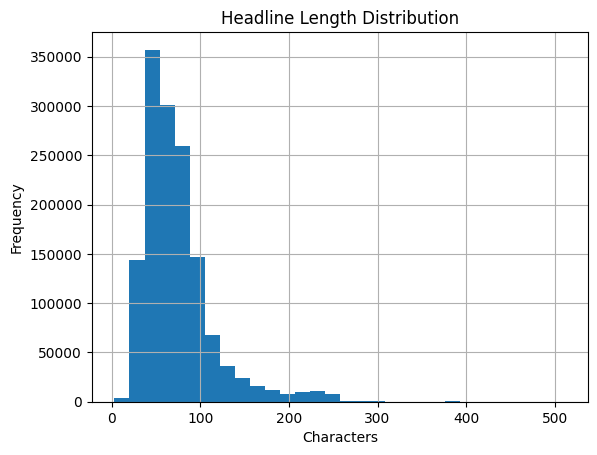

In [9]:
import matplotlib.pyplot as plt

df['headline_length'].hist(bins=30)

plt.title("Headline Length Distribution")
plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.show()

Count Articles Per Publisher

In [10]:
publisher_counts = df['publisher'].value_counts()

print(publisher_counts.head(10))

publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64


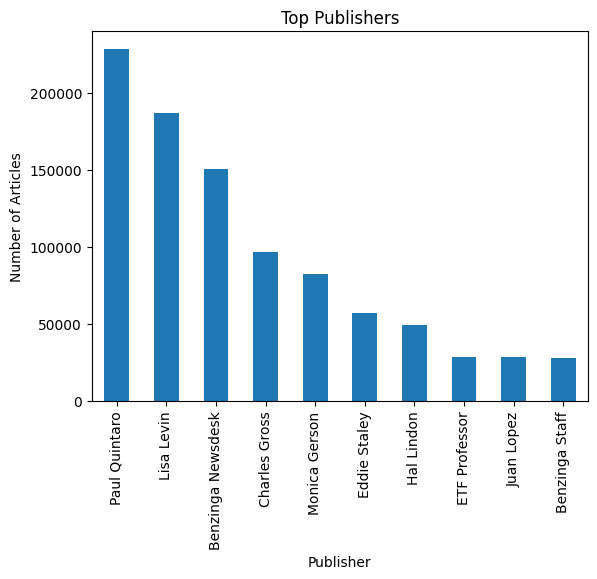

In [11]:
publisher_counts.head(10).plot(kind='bar')

plt.title("Top Publishers")
plt.xlabel("Publisher")
plt.ylabel("Number of Articles")
plt.show()

Publication Date Trends

In [12]:
df['date'] = pd.to_datetime(df['date'], format='mixed', utc=True)

In [13]:
df['date'] = pd.to_datetime(df['date'])

articles_per_day = df.groupby(df['date'].dt.date).size()

print(articles_per_day.head())

date
2009-02-14    1
2009-04-27    2
2009-04-29    1
2009-05-22    1
2009-05-27    6
dtype: int64


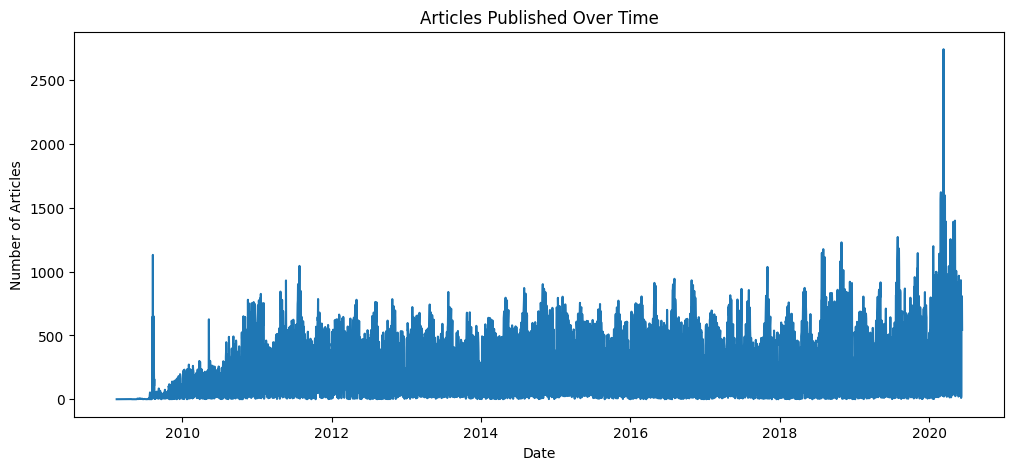

In [15]:
articles_per_day.plot(figsize=(12,5))

plt.title("Articles Published Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Articles")
plt.show()

Text Analysis (Topic Modeling)



Keyword Extraction

In [16]:
from collections import Counter
import re

Clean text

In [17]:
df['headline_clean'] = df['headline'].str.lower()
df['headline_clean'] = df['headline_clean'].apply(lambda x: re.sub(r'[^a-zA-Z ]', '', str(x)))

Count words

In [18]:
all_words = " ".join(df['headline_clean']).split()

word_counts = Counter(all_words)

print(word_counts.most_common(20))

[('to', 402906), ('of', 269814), ('on', 245082), ('for', 239535), ('in', 220612), ('the', 212863), ('m', 186060), ('vs', 162147), ('stocks', 161868), ('q', 157878), ('est', 140606), ('eps', 128929), ('from', 120713), ('shares', 114209), ('and', 113439), ('reports', 108707), ('update', 91680), ('market', 90880), ('earnings', 87185), ('with', 84204)]


Keyword Analysis

In [19]:
stopwords = set([
    "the", "a", "an", "and", "or", "to", "in", "for", "of", "on", "is", "are", "with"
])

filtered_words = [w for w in all_words if w not in stopwords]

word_counts = Counter(filtered_words)

print(word_counts.most_common(20))

[('m', 186060), ('vs', 162147), ('stocks', 161868), ('q', 157878), ('est', 140606), ('eps', 128929), ('from', 120713), ('shares', 114209), ('reports', 108707), ('update', 91680), ('market', 90880), ('earnings', 87185), ('sales', 79526), ('top', 78678), ('at', 78440), ('pt', 73054), ('up', 71367), ('week', 67669), ('announces', 66529), ('price', 64232)]


Phrase Extraction

In [20]:
from collections import Counter

bigrams = []

words = df['headline_clean'].str.split()

for sentence in words:
    for i in range(len(sentence)-1):
        bigrams.append(sentence[i] + " " + sentence[i+1])

bigram_counts = Counter(bigrams)

print(bigram_counts.most_common(20))

[('q eps', 81441), ('vs est', 78186), ('reports q', 66991), ('eps vs', 52038), ('price target', 47266), ('benzingas top', 44258), ('m vs', 42557), ('vs m', 41197), ('are trading', 40497), ('stocks moving', 40006), ('moving in', 39744), ('m est', 38748), ('shares of', 34849), ('sales m', 33404), ('market update', 33089), ('scheduled for', 32252), ('earnings scheduled', 32054), ('coverage on', 30563), ('in the', 29715), ('initiates coverage', 28979)]


Simple “Topic Modeling” without LDA

In [21]:
top_words = word_counts.most_common(100)

In [22]:
topics = {
    "earnings": ["earnings", "revenue", "profit", "eps"],
    "analyst": ["upgrade", "downgrade", "price target", "rating"],
    "health": ["fda", "approval", "drug", "trial"],
    "market": ["stock", "shares", "market", "rally"]
}

In [23]:
topic_counts = {t: 0 for t in topics}

for word in filtered_words:
    for topic, keywords in topics.items():
        if word in keywords:
            topic_counts[topic] += 1

print(topic_counts)

{'earnings': 254796, 'analyst': 21647, 'health': 32682, 'market': 248389}


Count topic occurrences

In [24]:
topic_counts = {t: 0 for t in topics}

for word in filtered_words:
    for topic, keywords in topics.items():
        if word in keywords:
            topic_counts[topic] += 1

print(topic_counts)

{'earnings': 254796, 'analyst': 21647, 'health': 32682, 'market': 248389}


Time Series Analysis of News Volume

In [28]:
daily_counts = df.groupby(df['date'].dt.date).size()
print(daily_counts.head())

date
2009-02-14    1
2009-04-27    2
2009-04-29    1
2009-05-22    1
2009-05-27    6
dtype: int64


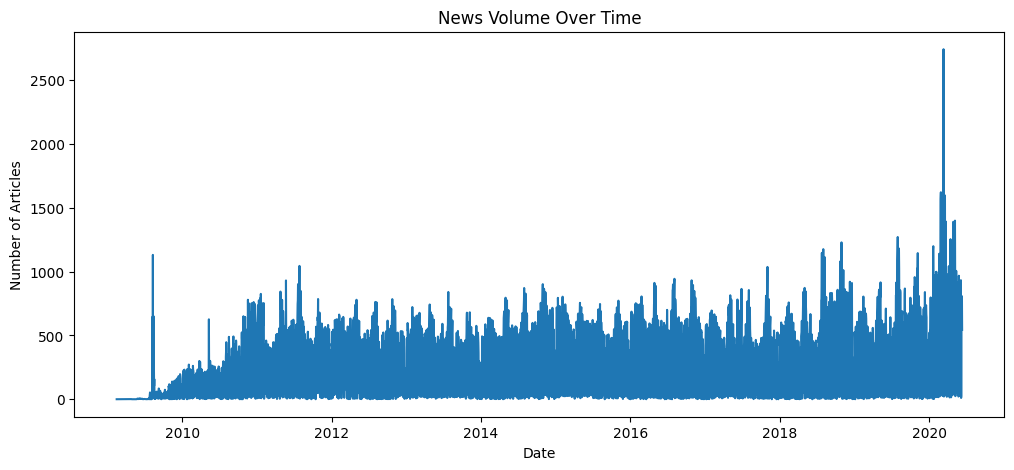

In [27]:
import matplotlib.pyplot as plt

daily_counts.plot(figsize=(12,5))

plt.title("News Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Articles")
plt.show()

Detect Spikes Automatically

In [29]:
mean =daily_counts.mean()
std = daily_counts.std()

spikes = daily_counts[daily_counts > mean + 2*std]

print(spikes)

date
2009-08-10    1130
2011-05-23     930
2011-07-28    1044
2016-08-04     943
2016-10-27     931
              ... 
2020-05-07    1398
2020-05-08     927
2020-05-13    1005
2020-05-26     967
2020-06-05     932
Length: 85, dtype: int64


Link Spikes to Market Events

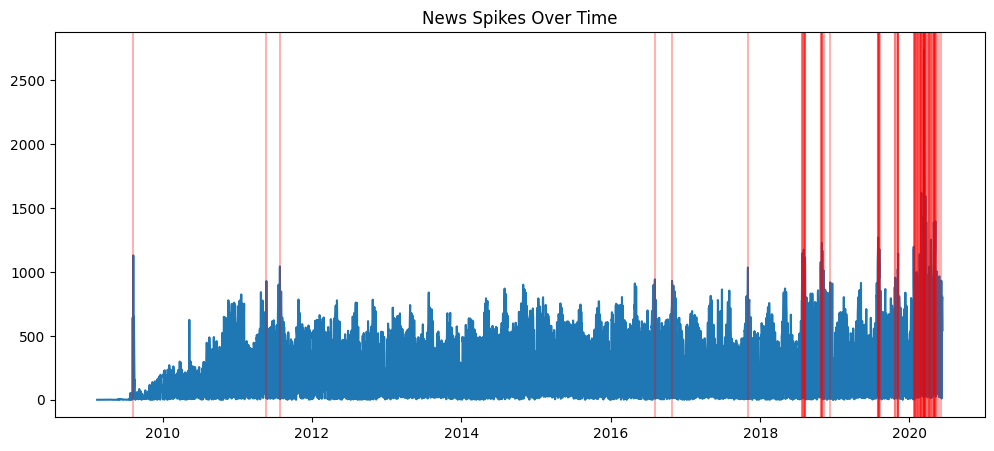

In [30]:
plt.figure(figsize=(12,5))
plt.plot(daily_counts)

for date in spikes.index:
    plt.axvline(x=date, color='red', alpha=0.3)

plt.title("News Spikes Over Time")
plt.show()

Publishing Time Analysis

In [31]:
df['hour'] = df['date'].dt.hour

In [32]:
hour_counts = df['hour'].value_counts().sort_index()
print(hour_counts)

hour
0     1351472
1          82
2          48
3          27
4          67
5          14
6          57
7          93
8        1469
9        1829
10       2476
11       5033
12       5527
13       5965
14       7669
15       5701
16       5732
17       2710
18       2075
19       1612
20       3939
21       2800
22        704
23        227
Name: count, dtype: int64


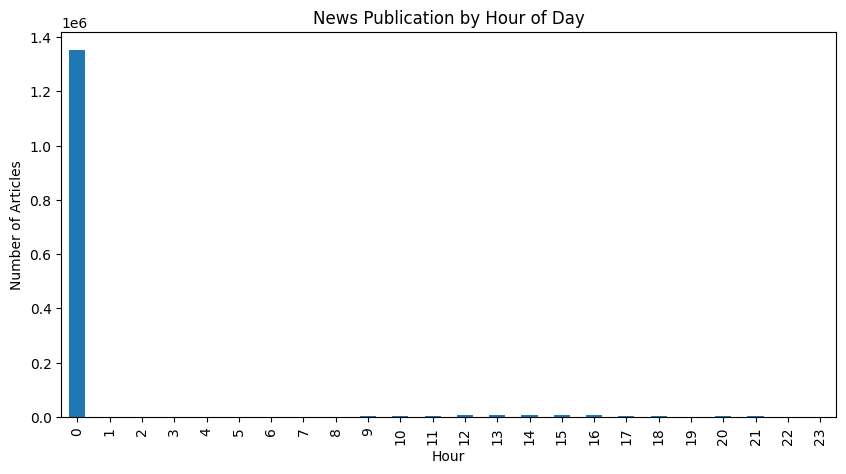

In [33]:
hour_counts.plot(kind='bar', figsize=(10,5))

plt.title("News Publication by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Articles")
plt.show()

Publisher Analysis

In [34]:
df['publisher'].head()

0    Benzinga Insights
1    Benzinga Insights
2           Lisa Levin
3           Lisa Levin
4           Vick Meyer
Name: publisher, dtype: str

Count publishers

In [35]:
publisher_counts = df['publisher'].value_counts()

print(publisher_counts.head(10))

publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64


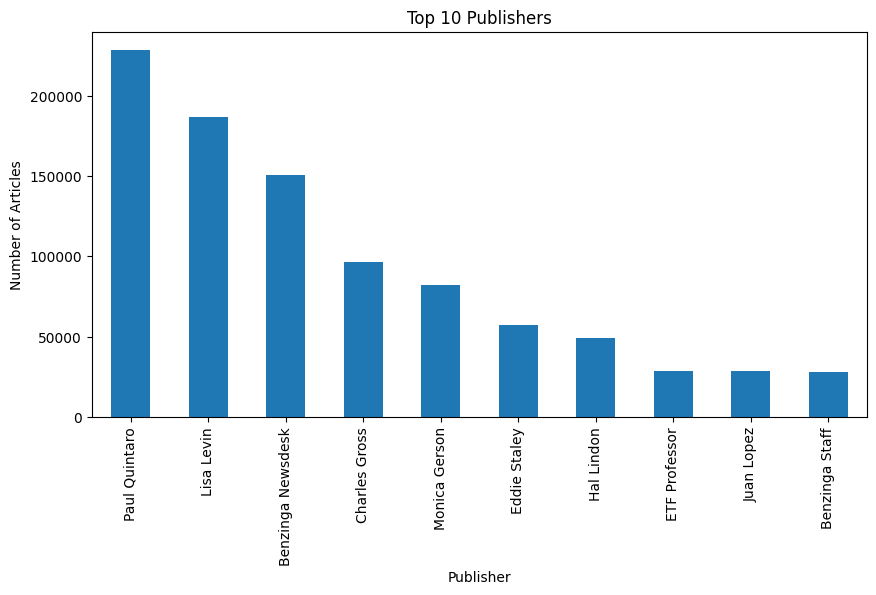

In [36]:
publisher_counts.head(10).plot(kind='bar', figsize=(10,5))

import matplotlib.pyplot as plt
plt.title("Top 10 Publishers")
plt.xlabel("Publisher")
plt.ylabel("Number of Articles")
plt.show()

Publishers Are Emails → Extract Domains

In [37]:
df['domain'] = df['publisher'].astype(str).str.extract(r'@(.+)$')

In [38]:
domain_counts = df['domain'].value_counts()

print(domain_counts.head(10))

domain
benzinga.com              7937
gmail.com                  139
andyswan.com                 5
investdiva.com               2
tothetick.com                2
eosdetroit.io                1
forextraininggroup.com       1
stockmetrix.net              1
Name: count, dtype: int64


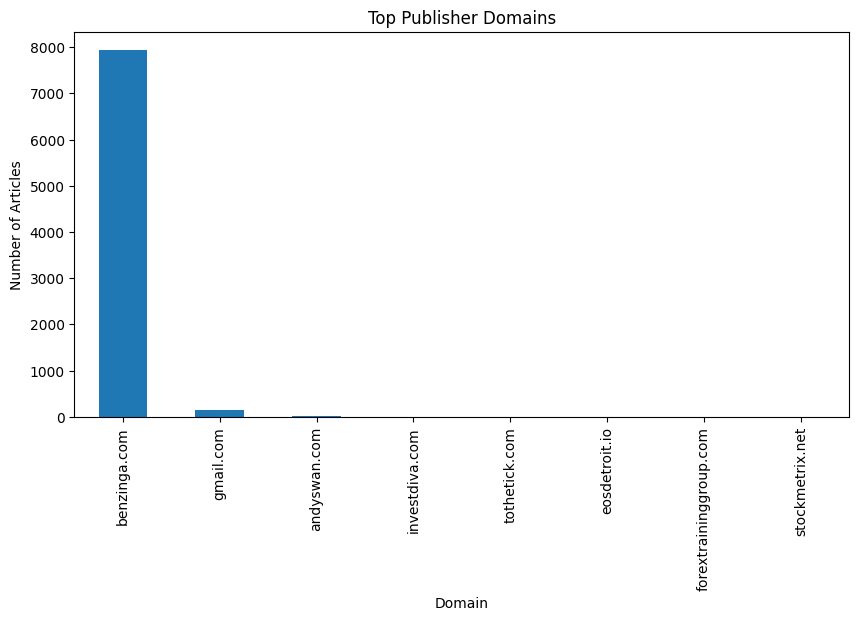

In [39]:
domain_counts.head(10).plot(kind='bar', figsize=(10,5))

plt.title("Top Publisher Domains")
plt.xlabel("Domain")
plt.ylabel("Number of Articles")
plt.show()

In [40]:
df.groupby('publisher')['headline'].count().sort_values(ascending=False).head(10)

publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: headline, dtype: int64